<a href="https://colab.research.google.com/github/giministk/ml/blob/main/%D0%94%D0%9F%D0%9E_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9612.2_%D0%93%D0%B5%D0%BE%D0%BC%D0%B0%D1%80%D0%BA%D0%B5%D1%82%D0%B8%D0%BD%D0%B3%D0%BE%D0%B2%D0%BE%D0%B5_%D0%B8%D1%81%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D1%82%D0%B5%D1%80%D1%80%D0%B8%D1%82%D0%BE%D1%80%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геомаркетинговое исследование территорий с применением методов машинного обучения**


## **Цель работы**


Овладеть методами пространственного анализа и машинного обучения для решения практической задачи определения оптимальных локаций размещения коммерческих объектов.

## **Введение**


В современном бизнесе местоположение коммерческого объекта играет ключевую роль в его успешности. Геомаркетинговый анализ позволяет объективно оценить привлекательность различных локаций, опираясь на количественные показатели и алгоритмы машинного обучения.

В рамках данной работы вы примените полный цикл пространственного анализа, включая сбор данных из открытых источников, обработку и агрегацию пространственной информации, обучение моделей машинного обучения и визуализацию результатов.

## **Задание**


Провести геомаркетинговое исследование для выбора оптимальных локаций размещения новых точек определенного типа бизнеса на территории выбранного города.

## **Порядок выполнения работы**

### **Часть 1. Подготовка данных и определение задачи**



1. **Индивидуальный выбор территории и типа бизнеса**:
   - Выберите город/район для проведения анализа (например, центральная часть Москвы, Санкт-Петербурга или любого другого крупного города)
   - Определите тип бизнеса для анализа (аптеки, продуктовые магазины, пункты выдачи заказов, рестораны определенной кухни и т.д.)
   - Обоснуйте свой выбор: почему данная территория и тип бизнеса интересны для анализа?

2. **Определение ключевых факторов успешности**:
   - Самостоятельно сформулируйте не менее 5 факторов, которые могут влиять на успешность выбранного типа бизнеса
   - Для каждого фактора определите, какими данными из OpenStreetMap его можно количественно описать
   - Составьте таблицу соответствия между факторами и тегами OpenStreetMap

3. **Сбор исходных данных**:
   - Настройте необходимые библиотеки из теоретического материала
   - Определите необходимую область интереса (ROI) с помощью интерактивной карты
   - Загрузите данные о существующих объектах вашего типа бизнеса и объектах инфраструктуры, связанных с выделенными вами факторами

In [ ]:
#выбираю Ногинск, тк могу объектично оценить результаты работы
#я главный фанат кофе, что тем более мне может помочь с оценкой
#если говорить об обосновании выбора: кофе любит много кто, это стало даже модно. Я могу достаточно хорошо провести оценку работы моей программы.
#и я просто очень люблю кофе

'''
выбор факторов:

1 - Потенциальный трафик (офисы) | OpenStreetMap: Здания с коммерческим назначением | building=commercial, building=office, office=company, amenity=bank
2 - Конкуренты | Существующие кофейни | amenity=cafe + cuisine=coffee_shop
3 - Транспортные узлы | Остановки автобусов, ж/д станции | highway=bus_stop, railway=station
4 - Туристическая привлекательность | Достопримечательности, музеи, памятники | tourism=attraction, tourism=museum, historic=*
5 - Учебные заведения | ВУЗы, колледжи, школы | amenity=university, amenity=college, amenity=school
6 - Плотность населения | Жилые здания | building=apartments, building=residential, landuse=residential

'''

!pip install scikit-learn geopandas h3pandas h3~=3.0 leafmap mapclassify matplotlib streamlit osmnx openrouteservice polyline -q

import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import h3
import h3pandas
import leafmap
import folium
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import box, Polygon, Point
import warnings
warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━

In [ ]:
place = "Ногинск"
graph = ox.graph_from_place(place)

In [ ]:
type(graph)

networkx.classes.multidigraph.MultiDiGraph

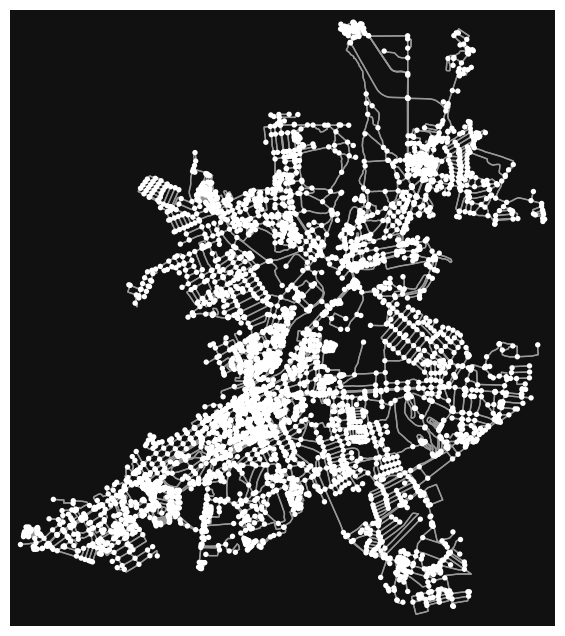

In [ ]:
fig, ax = ox.plot_graph(graph)

<Axes: >

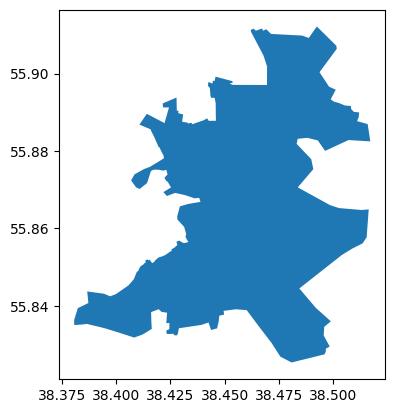

In [ ]:
area = ox.geocode_to_gdf(place)
area.plot()

In [ ]:
area.explore()

In [ ]:
factors_df = pd.DataFrame([
    {"№": 1, "Фактор": "Офисные сотрудники",
     "Почему важен": "Регулярный спрос в будние дни (утро/обед/после работы)",
     "Тег OSM": "building=commercial, office=company, amenity=bank"},
    {"№": 2, "Фактор": "Конкуренты",
     "Почему важен": "Оценка насыщенности рынка (высокая концентрация → высокая конкуренция)",
     "Тег OSM": "amenity=cafe + cuisine=coffee_shop"},
    {"№": 3, "Фактор": "Транспортная доступность",
     "Почему важен": "Высокий проходящий трафик (ж/д станция, автобусные остановки)",
     "Тег OSM": "railway=station, highway=bus_stop"},
    {"№": 4, "Фактор": "Туризм и достопримечательности",
     "Почему важен": "Привлечение гостей города (выходные и праздники)",
     "Тег OSM": "tourism=attraction, historic=monument"},
    {"№": 5, "Фактор": "Учебные заведения",
     "Почему важен": "Студенты и преподаватели — активные потребители кофе",
     "Тег OSM": "amenity=university, amenity=college, amenity=school"},
    {"№": 6, "Фактор": "Плотность населения",
     "Почему важен": "База постоянных клиентов из соседних домов",
     "Тег OSM": "building=apartments, building=residential"}
])

factors_df

,№,Фактор,Почему важен,Тег OSM
0,1,Офисные сотрудники,Регулярный спрос в будние дни (утро/обед/после...,"building=commercial, office=company, amenity=bank"
1,2,Конкуренты,Оценка насыщенности рынка (высокая концентраци...,amenity=cafe + cuisine=coffee_shop
2,3,Транспортная доступность,"Высокий проходящий трафик (ж/д станция, автобу...","railway=station, highway=bus_stop"
3,4,Туризм и достопримечательности,Привлечение гостей города (выходные и праздники),"tourism=attraction, historic=monument"
4,5,Учебные заведения,Студенты и преподаватели — активные потребител...,"amenity=university, amenity=college, amenity=s..."
5,6,Плотность населения,База постоянных клиентов из соседних домов,"building=apartments, building=residential"


In [ ]:
tags = {"amenity": "cafe", "cuisine": "coffee_shop"}
cafes = ox.features_from_place(place, tags)

len(cafes)

29

In [ ]:
cafes.head(10)

geometry addr:city  \
element id                                                
node    2462472051  POINT (38.46216 55.87703)   Ногинск   
        3352836347  POINT (38.43849 55.85588)       NaN   
        3953992259  POINT (38.44019 55.87791)       NaN   
        4215106939  POINT (38.40278 55.84388)       NaN   
        4242481082  POINT (38.44362 55.85125)       NaN   
        4261550629  POINT (38.43156 55.85507)       NaN   
        4756559208  POINT (38.44547 55.85241)       NaN   
        5328249323   POINT (38.44417 55.8539)       NaN   
        5585780234     POINT (38.4428 55.851)       NaN   
        5585780235  POINT (38.44277 55.85105)       NaN   

                                    addr:street amenity         name  \
element id                                                             
node    2462472051  улица Советской Конституции    cafe      Минутка   
        3352836347                          NaN    cafe      Самолет   
        3953992259                          NaN    cafe       Галина   
        4215106939                          NaN    cafe  Летнее кафе   
        4242481082                          NaN    cafe      Встреча   
        4261550629                          NaN    cafe          NaN   
        4756559208                          NaN    cafe       Халяль   
        5328249323                          NaN    cafe        Панда   
        5585780234                          NaN    cafe    Вкусняшка   
        5585780235                          NaN    cafe  Coffee Shop   

                   was:amenity name:en contact:instagram cuisine drink:coffee  \
element id                                                                      
node    2462472051         NaN     NaN               NaN     NaN          NaN   
        3352836347         NaN     NaN               NaN     NaN          NaN   
        3953992259         NaN     NaN               NaN     NaN          NaN   
        4215106939         NaN     NaN               NaN     NaN          NaN   
        4242481082        cafe     NaN               NaN     NaN          NaN   
        4261550629         NaN     NaN               NaN     NaN          NaN   
        4756559208         NaN     NaN               NaN     NaN          NaN   
        5328249323         NaN   Panda               NaN     NaN          NaN   
        5585780234         NaN     NaN               NaN     NaN          NaN   
        5585780235         NaN     NaN               NaN     NaN          NaN   

                    ... brand:wikidata contact:email contact:phone  \
element id          ...                                              
node    2462472051  ...            NaN           NaN           NaN   
        3352836347  ...            NaN           NaN           NaN   
        3953992259  ...            NaN           NaN           NaN   
        4215106939  ...            NaN           NaN           NaN   
        4242481082  ...            NaN           NaN           NaN   
        4261550629  ...            NaN           NaN           NaN   
        4756559208  ...            NaN           NaN           NaN   
        5328249323  ...            NaN           NaN           NaN   
        5585780234  ...            NaN           NaN           NaN   
        5585780235  ...            NaN           NaN           NaN   

                   contact:website building addr:postcode email phone  \
element id                                                              
node    2462472051             NaN      NaN           NaN   NaN   NaN   
        3352836347             NaN      NaN           NaN   NaN   NaN   
        3953992259             NaN      NaN           NaN   NaN   NaN   
        4215106939             NaN      NaN           NaN   NaN   NaN   
        4242481082             NaN      NaN           NaN   NaN   NaN   
        4261550629             NaN      NaN           NaN   NaN   NaN   
        4756559208             NaN      NaN           NaN   NaN  

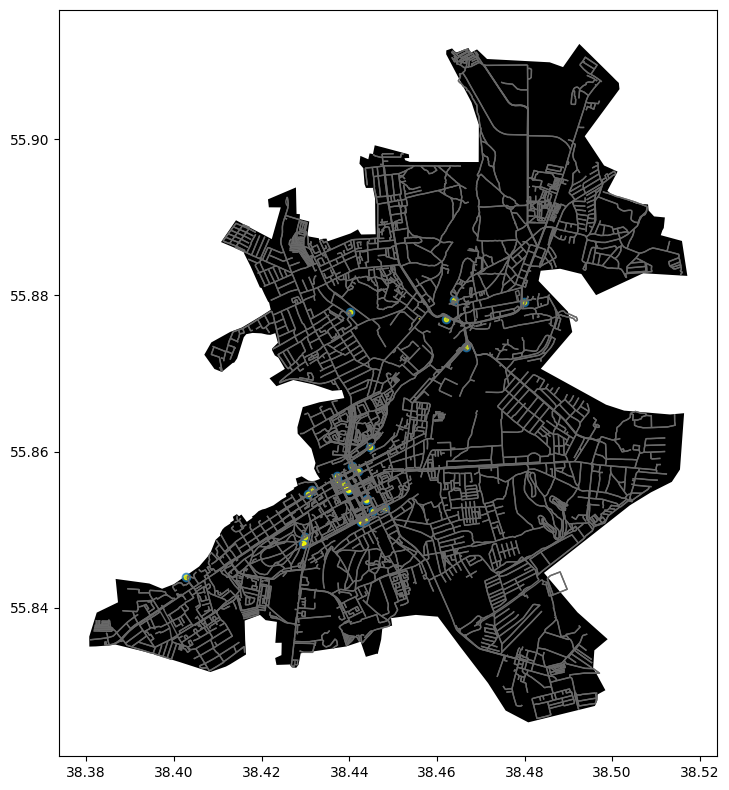

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

nodes, edges = ox.graph_to_gdfs(graph)
buildings = ox.features_from_place(place, tags)

area.plot(ax=ax, facecolor="black")

edges.plot(ax=ax, linewidth=1, edgecolor="dimgray")

buildings.plot(ax=ax, facecolor="silver", alpha=0.7)

cafes.plot(ax=ax, color="yellow", alpha=0.7, markersize=10)
plt.tight_layout()

### **Часть 2. Пространственное агрегирование и создание признаков**


1. **Создание гексагональной сетки**:
   - Самостоятельно определите оптимальную детализацию сетки H3 для вашего анализа
   - Обоснуйте выбор разрешения (resolution) сетки с учётом масштаба вашей территории и специфики бизнеса
   - Покройте территорию гексагональной сеткой выбранного разрешения

2. **Инженерия пространственных признаков**:
   - Определите радиусы для анализа ближнего и среднего окружения (могут отличаться от предложенных в теории в зависимости от специфики вашего бизнеса)
   - Разработайте и реализуйте не менее 10 пространственных признаков, описывающих характеристики каждой ячейки
   - **Дополнительное задание**: придумайте и реализуйте не менее 2 пространственных признаков, которых нет в теоретическом материале

3. **Анализ полученных признаков**:
   - Рассчитайте базовую статистику по каждому признаку
   - Исследуйте корреляции между признаками
   - Выявите и обработайте выбросы и пропущенные значения, если они имеются

In [ ]:
m = leafmap.Map(draw_control=True, basemap='CartoDB.Positron')
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [ ]:
bbox = m.user_roi_bounds()

if bbox:
    print(f"Выбранный bounding box: {bbox}")
else:
    bbox = [38.348, 55.8229, 38.5389, 55.93]
    print(f"Область не выбрана. Используем значение по умолчанию: {bbox}")

Область не выбрана. Используем значение по умолчанию: [38.348, 55.8229, 38.5389, 55.93]


In [ ]:
def load_osm_data(bbox):
    """
    Загружает данные из OpenStreetMap по заданному bounding box.

    Параметры:
        bbox: список координат [запад, юг, восток, север]

    Возвращает:
        dict: словарь с GeoDataFrame для каждого типа объектов
    """
    west, south, east, north = bbox

    tags = {
        'schools': {'amenity': 'school'},
        'competitors': {"amenity": "cafe", "cuisine": "coffee_shop"},
        'university': {'amenity': 'university'},
        'mall': {'shop': 'mall'},
        'fountain': {'amenity': 'fountain'},
        'parks': {'leisure': 'park'},
        'railway': {'railway': 'station'},
        'highway': {'highway': 'bus_stop'},
        'building': {'building': ['apartments', 'residential', 'house']},
        'office': {'building': ['commercial', 'office', 'retail']}
    }

    data = {}
    for key, tag in tags.items():
        print(f"Загрузка {key}...")
        try:
            gdf = ox.features_from_bbox((west, south, east, north), tags=tag)
            data[key] = gdf
        except:
            print(f"Нет данных для {key} в заданном регионе. Создаём пустой GeoDataFrame.")
            # Создаём пустой GeoDataFrame с колонкой 'geometry' и устанавливаем CRS
            data[key] = gpd.GeoDataFrame(columns=['geometry'], crs="EPSG:4326")

    return data

In [ ]:
data = load_osm_data(bbox)

Загрузка schools...
Загрузка competitors...
Загрузка university...
Загрузка mall...
Загрузка fountain...
Загрузка parks...
Загрузка railway...
Загрузка highway...
Загрузка building...
Загрузка office...


In [ ]:
crs_proj = "EPSG:3857"

for key in data.keys():
    if not data[key].empty and 'geometry' in data[key].columns:
        data[key] = data[key].to_crs(crs_proj)
    else:
        data[key] = gpd.GeoDataFrame(columns=['geometry'], crs=crs_proj)

In [ ]:
resolution = 9

bbox_polygon = box(*bbox)
h3_indexes = list(h3.polyfill_geojson(bbox_polygon.__geo_interface__, resolution))
h3_geometries = [Polygon(h3.h3_to_geo_boundary(h, geo_json=True)) for h in h3_indexes]

h3_gdf = gpd.GeoDataFrame(
    {'h3_index': h3_indexes, 'geometry': h3_geometries},
    crs="EPSG:4326"
).to_crs(crs_proj)

In [ ]:
def analyze_h3_cell(geom):
    """
    Анализирует одну ячейку H3 с использованием буферных зон.

    Параметры:
        geom: геометрия ячейки (полигон)

    Возвращает:
        tuple: (кол-во школ, кол-во метро, длина велодорожек, площадь парков)
    """
    buffer_1500m = geom.buffer(1500)
    buffer_500m = geom.buffer(500)

    # Используем пространственный фильтр по пересечению (.intersects()):
    # 1. Находим объекты, которые попадают внутрь или касаются границ созданного буфера (800м или 1600м).
    # 2. Выбираем только эти строки из исходных данных.
    # 3. Считаем их количество (.shape[0]) для точечных объектов или сумму мер (.length.sum() / .area.sum()) для линейных и площадных.

    num_schools = data['schools'][data['schools'].geometry.intersects(buffer_1500m)].shape[0]
    num_competitors = data['competitors'][data['competitors'].geometry.intersects(buffer_500m)].shape[0]
    num_univercities = data['university'][data['university'].geometry.intersects(buffer_1500m)].shape[0]
    num_highway = data['highway'][data['highway'].geometry.intersects(buffer_500m)].shape[0]
    num_railway = data['railway'][data['railway'].geometry.intersects(buffer_1500m)].shape[0]
    num_mall = data['mall'][data['mall'].geometry.intersects(buffer_500m)].shape[0]
    num_building = data['building'][data['building'].geometry.intersects(buffer_1500m)].shape[0]
    num_fountain = data['fountain'][data['fountain'].geometry.intersects(buffer_500m)].shape[0]
    num_office = data['office'][data['office'].geometry.intersects(buffer_500m)].shape[0]
    park_area = data['parks'][data['parks'].geometry.intersects(buffer_1500m)].area.sum()

    return num_schools, num_building, num_office, num_univercities, num_competitors, num_railway, num_highway, num_fountain, num_mall, park_area

In [ ]:
h3_gdf[['num_schools', 'num_building', 'num_office', 'num_univercities', 'num_competitors', 'num_railway', 'num_highway', 'num_fountain', 'num_mall', 'park_area']] = \
    h3_gdf.geometry.apply(lambda geom: pd.Series(analyze_h3_cell(geom)))

In [ ]:
h3_gdf[['num_schools', 'num_building', 'num_office', 'num_univercities', 'num_competitors', 'num_railway', 'num_highway', 'num_fountain', 'num_mall', 'park_area']].describe()

,num_schools,num_building,num_office,num_univercities,num_competitors,num_railway,num_highway,num_fountain,num_mall,park_area
count,1423.000000,1423.000000,1423.000000,1423.000000,1423.000000,1423.000000,1423.000000,1423.000000,1423.000000,1.423000e+03
mean,0.632467,24.035137,0.437105,0.024596,0.156711,0.023893,1.094870,0.094870,0.106817,1.196455e+05
std,1.454123,45.178270,1.259038,0.154945,0.929306,0.152770,1.831163,0.539699,0.768473,3.692175e+05
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
50%,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
75%,1.000000,22.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000e+00
max,10.000000,232.000000,16.000000,1.000000,14.000000,1.000000,10.000000,6.000000,12.000000,1.862435e+06


In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
columns_to_normalize = ['num_schools', 'num_building', 'num_office', 'num_univercities', 'num_competitors', 'num_railway', 'num_highway', 'num_fountain', 'num_mall', 'park_area']

In [ ]:
h3_gdf[columns_to_normalize] = scaler.fit_transform(h3_gdf[columns_to_normalize])
h3_gdf['index_score'] = h3_gdf[columns_to_normalize].sum(axis=1)

In [ ]:
import numpy as np

# num_office	0.25	Офисные сотрудники — главные потребители кофе круглый год
# num_railway	0.15	ЖД станции — стабильный высокий трафик всегда
# num_highway	0.12	Остановки — постоянный поток людей
# num_mall	0.12	ТЦ — высокая проходимость в любую погоду
# num_building	0.10	Жилые дома — постоянные клиенты
# num_univercities	0.08	Студенты (в учебный год, но учебный год длинный)
# park_area	0.1	Парки — трафик есть, но ниже, чем у транспорта
# num_schools	0.01	Школы — родители утром и днём
# num_fountain	0.04	Фонтаны — зоны притяжения, но специфичны
# num_college	0.03

weights_array = np.array([0.007, 0.408, 0.204, 0.054,	-0.102, 0.068, 0.082, 0.027, 0.116, 0.136])
print('проверка', weights_array.sum())
# Взвешенный индекс (матричное умножение)
h3_gdf['index_score'] = h3_gdf[columns_to_normalize].values @ weights_array

проверка 1.0


In [ ]:
h3_gdf[['num_schools', 'num_building', 'num_office', 'num_univercities', 'num_competitors', 'num_railway', 'num_highway', 'num_fountain', 'num_mall', 'park_area', 'index_score']].describe()

,num_schools,num_building,num_office,num_univercities,num_competitors,num_railway,num_highway,num_fountain,num_mall,park_area,index_score
count,1423.000000,1423.000000,1423.000000,1423.000000,1423.000000,1423.000000,1423.000000,1423.000000,1423.000000,1423.000000,1423.000000
mean,0.063247,0.103600,0.027319,0.024596,0.011194,0.023893,0.109487,0.015812,0.008901,0.064241,0.069270
std,0.145412,0.194734,0.078690,0.154945,0.066379,0.152770,0.183116,0.089950,0.064039,0.198245,0.121476
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.001821
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.008621,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.015828
75%,0.100000,0.094828,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000,0.061183
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.750964


In [ ]:
top5 = h3_gdf.sort_values(by='index_score', ascending=False).head()
top5

,h3_index,geometry,num_schools,num_building,num_office,num_univercities,num_competitors,num_railway,num_highway,num_fountain,num_mall,park_area,index_score
825,89118c892afffff,"POLYGON ((4279192.155 7529679.67, 4279458.291 ...",0.9,0.762931,0.6875,0.0,0.857143,1.0,0.7,0.833333,0.833333,1.000000,0.750964
1322,89118c892a3ffff,"POLYGON ((4278614.393 7529744.728, 4278880.536...",0.9,0.689655,0.7500,0.0,0.857143,1.0,0.6,1.000000,1.000000,1.000000,0.749451
585,89118c892abffff,"POLYGON ((4278835.066 7529171.093, 4279101.189...",0.5,0.586207,1.0000,0.0,1.000000,1.0,0.9,0.500000,0.916667,1.000000,0.742306
1350,89118c89233ffff,"POLYGON ((4279412.795 7529106.011, 4279678.911...",0.6,0.625000,0.6875,0.0,0.785714,1.0,0.7,0.333333,0.750000,0.877457,0.660041
621,89118c892a7ffff,"POLYGON ((4278971.487 7530253.352, 4279237.644...",1.0,0.771552,0.7500,0.0,0.714286,1.0,0.5,1.000000,0.750000,0.224996,0.655535


In [ ]:
h3_gdf_viz = h3_gdf.to_crs("EPSG:4326")

map_h3 = leafmap.Map(
    center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2],
    zoom=11, basemap='CartoDB.Positron'
)

map_h3.add_data(
    h3_gdf_viz,
    column="index_score",
    cmap="OrRd",
    k = 10,
    legend_title="Индекс успеха",
    layer_name="H3 Сетка",
    style={
        "stroke": True,
        "weight": 0,
        "fillOpacity": 0.7,
    }
)

map_h3.add_data(
    top5,
    column='index_score',
    cmap="Blues",  # красный цвет для выделения
    k = 6,
    layer_name="ТОП-5 локаций",
    style={
        "stroke": True,
        "weight": 2,
        "color": "red",
        "fillOpacity": 0.5,
    },
)

map_h3

Map(center=[55.87645, 38.44345], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

### **Часть 3. Моделирование привлекательности локаций**



1. **Подготовка целевой переменной**:
   - Определите, как будет сформирована целевая переменная для вашей задачи (по умолчанию: наличие объектов выбранного типа в ячейке)
   - Исследуйте распределение целевой переменной и оцените её сбалансированность
   - При необходимости, предложите стратегию работы с несбалансированными данными

2. **Разработка моделей машинного обучения**:
   - Реализуйте и обучите несколько моделей (минимум 2) для предсказания привлекательности локации
   - Проведите оценку важности признаков для каждой модели
   - Сравните модели по метрикам качества и выберите наилучшую
   - **Дополнительное задание**: настройте гиперпараметры модели с помощью поиска по сетке (GridSearchCV) или случайного поиска (RandomSearchCV)

3. **Улучшение модели с помощью кластеризации**:
   - Выполните кластеризацию ячеек по их характеристикам
   - Определите оптимальное число кластеров с помощью метода локтя или силуэта
   - Визуализируйте результаты кластеризации
   - Проверьте, улучшает ли добавление информации о кластерах качество основной модели

In [ ]:
columns = ['num_schools', 'num_building', 'num_office', 'num_univercities', 'num_competitors', 'num_railway', 'num_highway', 'num_fountain', 'num_mall', 'park_area']

X = h3_gdf[columns].copy()
y = h3_gdf['index_score'].copy()

X_df = pd.DataFrame(X, columns=columns)
X_df.index = h3_gdf.index
y.index = h3_gdf.index

print("Размерность набора данных:", X.shape)
X_df.head(10)

Размерность набора данных: (1423, 10)


,num_schools,num_building,num_office,num_univercities,num_competitors,num_railway,num_highway,num_fountain,num_mall,park_area
0,0.0,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.023149
2,0.0,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
5,0.0,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
6,0.1,0.396552,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
7,0.0,0.008621,0.0000,0.0,0.0,0.0,0.2,0.0,0.0,0.000000
8,0.0,0.000000,0.0625,0.0,0.0,0.0,0.4,0.0,0.0,0.000000
9,0.0,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.4, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

<Axes: title={'center': 'Важности признаков'}>

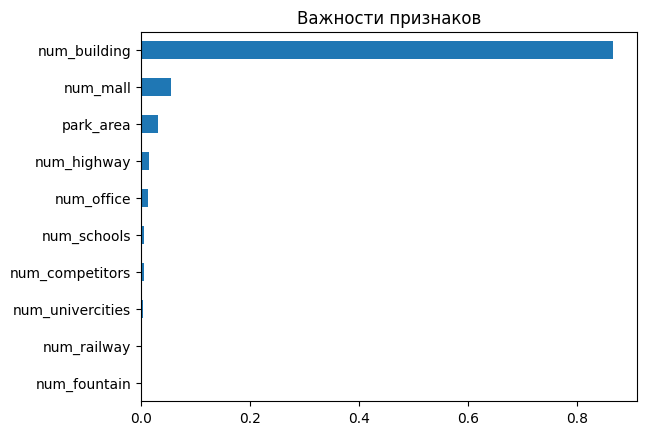

In [ ]:
feat_imp = pd.Series(rf.feature_importances_, index=columns)
feat_imp.sort_values().plot(kind='barh', title='Важности признаков')

In [ ]:
results = []

r2_rf = r2_score(y_test, rf_pred)
mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
results.append({'Model': 'Random Forest', 'R2': r2_rf, 'MAE': mae_rf, 'RMSE': rmse_rf})


r2_gb = r2_score(y_test, gb_pred)
mae_gb = mean_absolute_error(y_test, gb_pred)
rmse_gb = np.sqrt(mean_squared_error(y_test, gb_pred))
results.append({'Model': 'Gradient Boosting', 'R2': r2_gb, 'MAE': mae_gb, 'RMSE': rmse_gb})

pd.DataFrame(results).sort_values('R2', ascending=False)

,Model,R2,MAE,RMSE
1,Gradient Boosting,0.988875,0.005708,0.013529
0,Random Forest,0.983015,0.005723,0.016717


In [ ]:
from sklearn.model_selection import GridSearchCV

n_estimators = [int(x) for x in range(50, 251, 10)]
learning_rate = np.arange(0.1, 2.0, 0.2)
max_depth = [int(x) for x in range(1, 8)]
max_depth.append(None)

param_grid = {
    'n_estimators': n_estimators
}

param2_grid = {
    'n_estimators': n_estimators,
    'learning_rate': learning_rate,
    'max_depth': max_depth
}

rf_cv = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)
rf_cv.fit(X_train, y_train)
gb_cv = GridSearchCV(estimator=gb, param_grid=param2_grid, cv=5, verbose=1, n_jobs=-1)
gb_cv.fit(X_train, y_train)

best_params_rf = rf_cv.best_params_
best_model_rf = rf_cv.best_estimator_
r2_best_rf = r2_score(y_test, best_model_rf.predict(X_test))

best_params_gb = gb_cv.best_params_
best_model_gb = gb_cv.best_estimator_
r2_best_gb = r2_score(y_test, best_model_gb.predict(X_test))

print(f"Лучшие параметры Random Forest: {best_params_rf}; R2: {r2_best_rf}")
print(f"Лучшие параметры Gradient Boosting: {best_params_gb}; R2: {r2_best_gb}")

Fitting 5 folds for each of 21 candidates, totalling 105 fits
Fitting 5 folds for each of 1680 candidates, totalling 8400 fits
Лучшие параметры Random Forest: {'n_estimators': 80}; R2: 0.9829586607219619
Лучшие параметры Gradient Boosting: {'learning_rate': np.float64(1.3000000000000003), 'max_depth': 1, 'n_estimators': 250}; R2: 0.9945260554531684


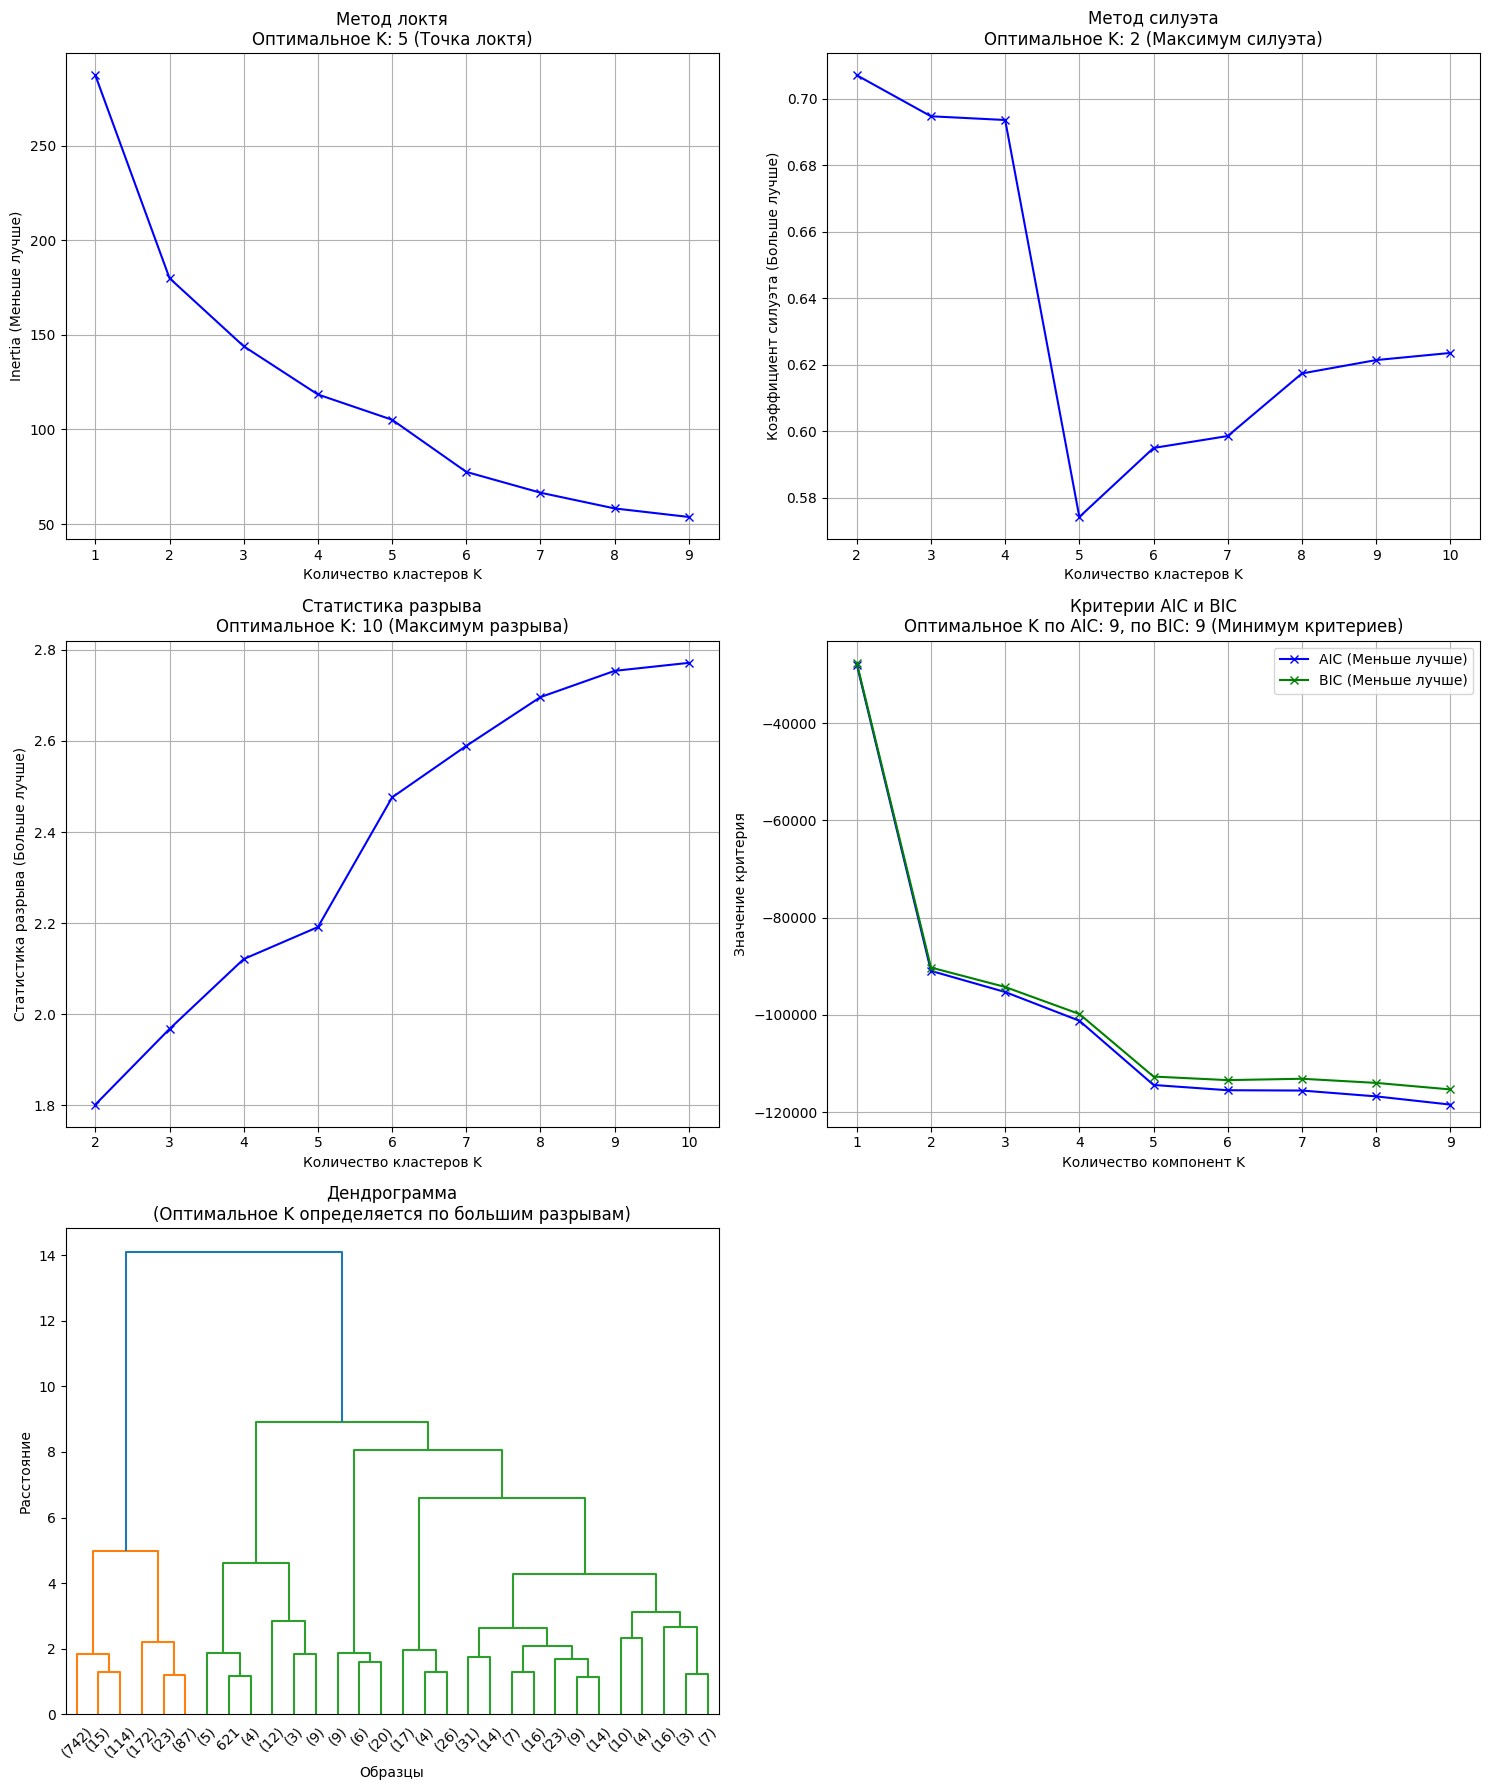

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# Диапазон чисел кластеров для анализа
K = range(1, 10)

# 1. Метод локтя (Elbow Method)
inertia = []
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Определение оптимального K по методу локтя
diff_inertia = np.diff(inertia)
diff_diff_inertia = np.diff(diff_inertia)
elbow_point = np.argmin(diff_diff_inertia) + 2  # +2 из-за порядка дифференцирования

# 2. Метод силуэта (Silhouette Method)
silhouette_scores = []
K_silhouette = range(2, 11)  # Силуэт не определяется для k=1
for k in K_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Определение оптимального K по методу силуэта
optimal_k_silhouette = K_silhouette[np.argmax(silhouette_scores)]

# 3. Статистика разрыва (Gap Statistic)
def compute_gap_statistic(X, nrefs=5, max_clusters=10):
    gaps = np.zeros(max_clusters - 1)
    results = np.zeros(max_clusters - 1)
    for k in range(1, max_clusters):
        km = KMeans(n_clusters=k+1, random_state=42)
        km.fit(X)
        disp = km.inertia_
        results[k - 1] = disp

        ref_disps = np.zeros(nrefs)
        for i in range(nrefs):
            random_reference = np.random.random_sample(size=X.shape)
            km_ref = KMeans(n_clusters=k+1, random_state=42)
            km_ref.fit(random_reference)
            ref_disp = km_ref.inertia_
            ref_disps[i] = ref_disp
        gap = np.log(np.mean(ref_disps)) - np.log(disp)
        gaps[k - 1] = gap
    return gaps

gaps = compute_gap_statistic(X, nrefs=5, max_clusters=10)
K_gap = range(2, 11)

# Определение оптимального K по статистике разрыва
optimal_k_gap = K_gap[np.argmax(gaps)]

# 4. Критерии AIC и BIC для моделей смеси гауссовых распределений
aic_scores = []
bic_scores = []
for k in K:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X)
    aic_scores.append(gmm.aic(X))
    bic_scores.append(gmm.bic(X))

# Определение оптимального K по AIC и BIC
optimal_k_aic = K[np.argmin(aic_scores)]
optimal_k_bic = K[np.argmin(bic_scores)]

# 5. Иерархическая кластеризация с дендрограммой
linked = linkage(X, 'ward')

# Построение графиков
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# График 1: Метод локтя
axes[0, 0].plot(K, inertia, 'bx-')
axes[0, 0].set_xlabel('Количество кластеров K')
axes[0, 0].set_ylabel('Inertia (Меньше лучше)')
axes[0, 0].set_title(f'Метод локтя\nОптимальное K: {elbow_point} (Точка локтя)')
axes[0, 0].grid(True)

# График 2: Метод силуэта
axes[0, 1].plot(K_silhouette, silhouette_scores, 'bx-')
axes[0, 1].set_xlabel('Количество кластеров K')
axes[0, 1].set_ylabel('Коэффициент силуэта (Больше лучше)')
axes[0, 1].set_title(f'Метод силуэта\nОптимальное K: {optimal_k_silhouette} (Максимум силуэта)')
axes[0, 1].grid(True)

# График 3: Статистика разрыва
axes[1, 0].plot(K_gap, gaps, 'bx-')
axes[1, 0].set_xlabel('Количество кластеров K')
axes[1, 0].set_ylabel('Статистика разрыва (Больше лучше)')
axes[1, 0].set_title(f'Статистика разрыва\nОптимальное K: {optimal_k_gap} (Максимум разрыва)')
axes[1, 0].grid(True)

# График 4: Критерии AIC и BIC
axes[1, 1].plot(K, aic_scores, 'bx-', label='AIC (Меньше лучше)')
axes[1, 1].plot(K, bic_scores, 'gx-', label='BIC (Меньше лучше)')
axes[1, 1].set_xlabel('Количество компонент K')
axes[1, 1].set_ylabel('Значение критерия')
axes[1, 1].set_title(f'Критерии AIC и BIC\nОптимальное K по AIC: {optimal_k_aic}, по BIC: {optimal_k_bic} (Минимум критериев)')
axes[1, 1].legend()
axes[1, 1].grid(True)

# График 5: Дендрограмма
dendrogram(linked, ax=axes[2, 0], truncate_mode='lastp', p=30)
axes[2, 0].set_title('Дендрограмма\n(Оптимальное K определяется по большим разрывам)')
axes[2, 0].set_xlabel('Образцы')
axes[2, 0].set_ylabel('Расстояние')

fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show()

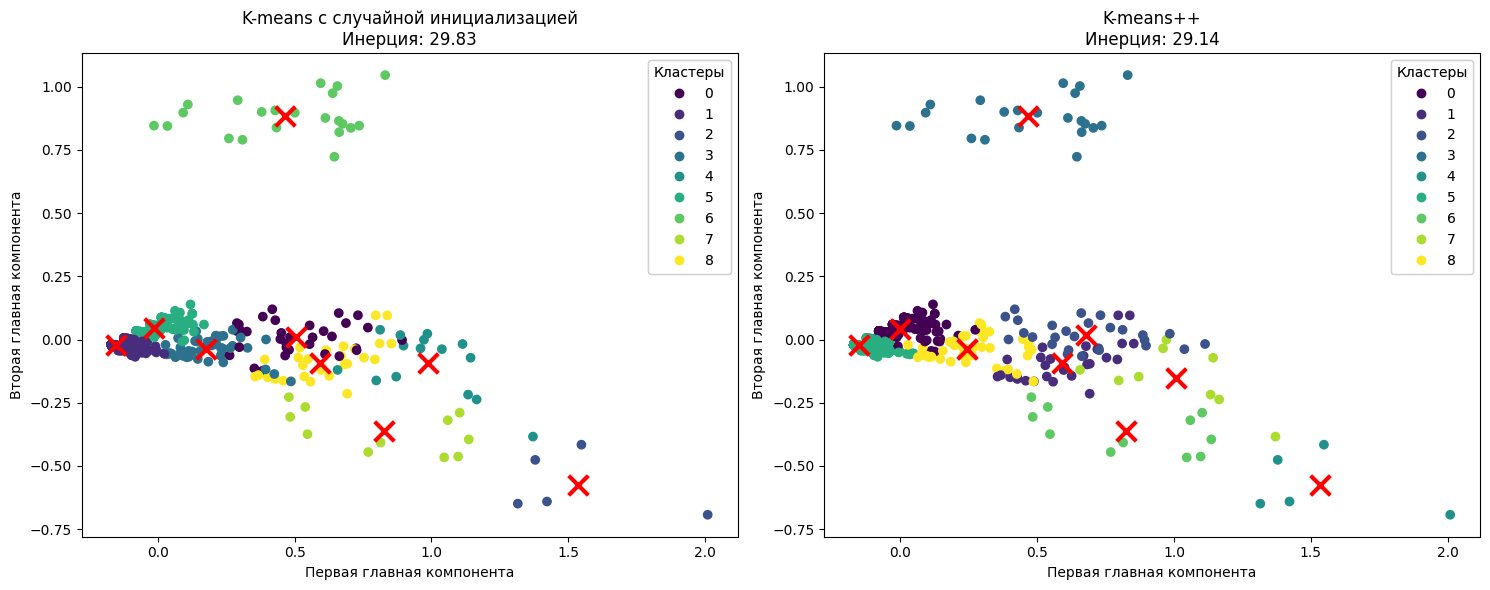

Количество итераций для K-means с случайной инициализацией: 17
Количество итераций для K-means++: 9
Инерция K-means с случайной инициализацией: 29.83
Инерция K-means++: 29.14


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
#K-means с случайной инициализацией
kmeans_random = KMeans(n_clusters=9, init='random', n_init=10, random_state=42)
kmeans_random.fit(X_train)
labels_random = kmeans_random.labels_

# K-means++
kmeans_plus = KMeans(n_clusters=9, init='k-means++', n_init=10, random_state=42)
kmeans_plus.fit(X_train)
labels_plus = kmeans_plus.labels_

# Визуализация результатов K-means с случайной инициализацией
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_random, cmap='viridis')
ax1.scatter(pca.transform(kmeans_random.cluster_centers_)[:, 0],
           pca.transform(kmeans_random.cluster_centers_)[:, 1],
           marker='x', s=200, linewidths=3, color='r', label='Центроиды')
ax1.set_title('K-means с случайной инициализацией\nИнерция: {:.2f}'.format(kmeans_random.inertia_))
ax1.set_xlabel('Первая главная компонента')
ax1.set_ylabel('Вторая главная компонента')
ax1.legend()

# Визуализация результатов K-means++
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_plus, cmap='viridis')
ax2.scatter(pca.transform(kmeans_plus.cluster_centers_)[:, 0],
           pca.transform(kmeans_plus.cluster_centers_)[:, 1],
           marker='x', s=200, linewidths=3, color='r', label='Центроиды')
ax2.set_title('K-means++\nИнерция: {:.2f}'.format(kmeans_plus.inertia_))
ax2.set_xlabel('Первая главная компонента')
ax2.set_ylabel('Вторая главная компонента')
ax2.legend()

# Добавляем легенду для кластеров
legend1 = ax1.legend(*scatter1.legend_elements(), title="Кластеры", loc="upper right")
ax1.add_artist(legend1)
legend2 = ax2.legend(*scatter2.legend_elements(), title="Кластеры", loc="upper right")
ax2.add_artist(legend2)

plt.tight_layout()
plt.show()

# Сравнение количества итераций
print(f"Количество итераций для K-means с случайной инициализацией: {kmeans_random.n_iter_}")
print(f"Количество итераций для K-means++: {kmeans_plus.n_iter_}")

# Сравнение инерции (суммы квадратов расстояний до ближайших центров кластеров)
print(f"Инерция K-means с случайной инициализацией: {kmeans_random.inertia_:.2f}")
print(f"Инерция K-means++: {kmeans_plus.inertia_:.2f}")

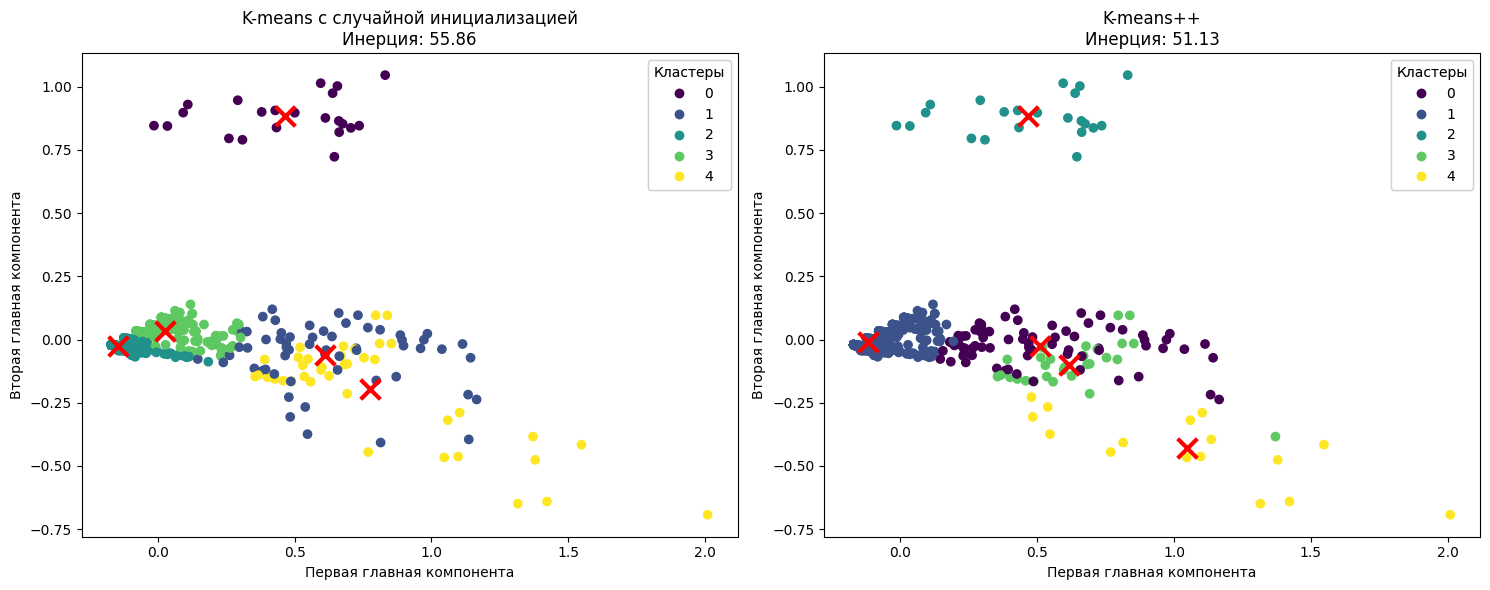

Количество итераций для K-means с случайной инициализацией: 11
Количество итераций для K-means++: 6
Инерция K-means с случайной инициализацией: 55.86
Инерция K-means++: 51.13


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
#K-means с случайной инициализацией
kmeans_random = KMeans(n_clusters=5, init='random', n_init=10, random_state=42)
kmeans_random.fit(X_train)
labels_random = kmeans_random.labels_

# K-means++
kmeans_plus = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
kmeans_plus.fit(X_train)
labels_plus = kmeans_plus.labels_

# Визуализация результатов K-means с случайной инициализацией
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_random, cmap='viridis')
ax1.scatter(pca.transform(kmeans_random.cluster_centers_)[:, 0],
           pca.transform(kmeans_random.cluster_centers_)[:, 1],
           marker='x', s=200, linewidths=3, color='r', label='Центроиды')
ax1.set_title('K-means с случайной инициализацией\nИнерция: {:.2f}'.format(kmeans_random.inertia_))
ax1.set_xlabel('Первая главная компонента')
ax1.set_ylabel('Вторая главная компонента')
ax1.legend()

# Визуализация результатов K-means++
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_plus, cmap='viridis')
ax2.scatter(pca.transform(kmeans_plus.cluster_centers_)[:, 0],
           pca.transform(kmeans_plus.cluster_centers_)[:, 1],
           marker='x', s=200, linewidths=3, color='r', label='Центроиды')
ax2.set_title('K-means++\nИнерция: {:.2f}'.format(kmeans_plus.inertia_))
ax2.set_xlabel('Первая главная компонента')
ax2.set_ylabel('Вторая главная компонента')
ax2.legend()

# Добавляем легенду для кластеров
legend1 = ax1.legend(*scatter1.legend_elements(), title="Кластеры", loc="upper right")
ax1.add_artist(legend1)
legend2 = ax2.legend(*scatter2.legend_elements(), title="Кластеры", loc="upper right")
ax2.add_artist(legend2)

plt.tight_layout()
plt.show()

# Сравнение количества итераций
print(f"Количество итераций для K-means с случайной инициализацией: {kmeans_random.n_iter_}")
print(f"Количество итераций для K-means++: {kmeans_plus.n_iter_}")

# Сравнение инерции (суммы квадратов расстояний до ближайших центров кластеров)
print(f"Инерция K-means с случайной инициализацией: {kmeans_random.inertia_:.2f}")
print(f"Инерция K-means++: {kmeans_plus.inertia_:.2f}")

0.6898475518416931
368.8206941200371
1.0458932068427644
0.5701073004456119
392.5299077216873
1.05078196664183
0.30876269516424226
20.179872377638297
1.6367581848141048
0.4772484966906408
13.773687291211234
1.5029799736521507
0.6566014315565621
345.3208894468558
1.0492939241035213
0.5313207744276893
363.0120490027733
0.9952613323724214


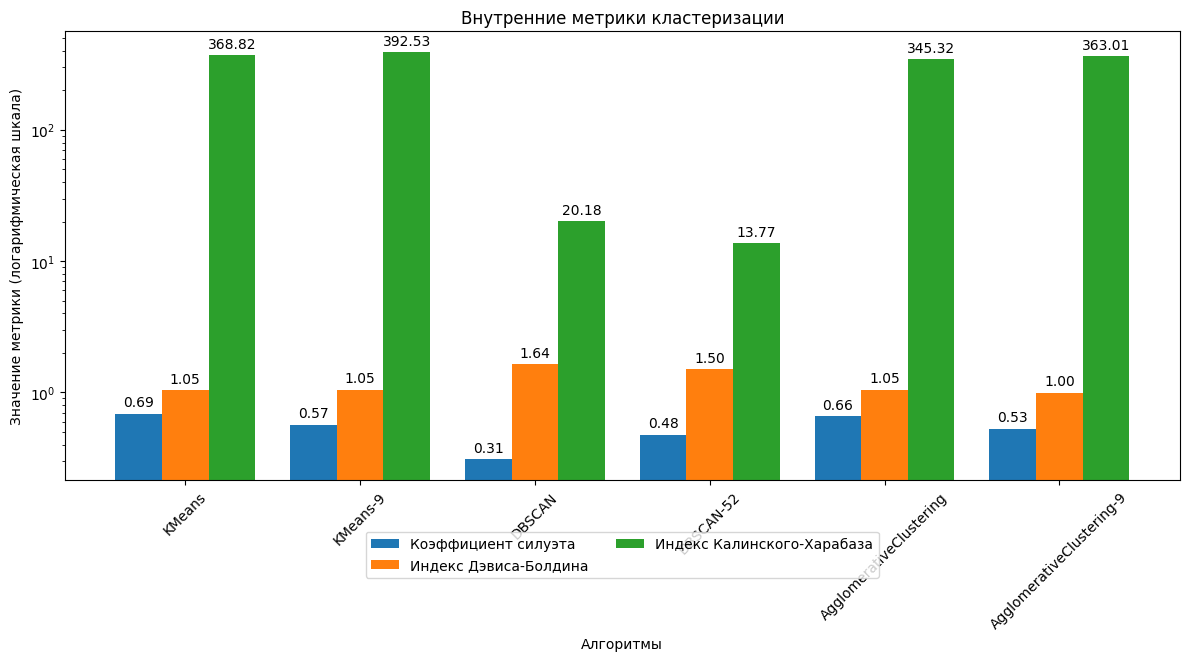

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    adjusted_rand_score,
    v_measure_score,
    normalized_mutual_info_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from scipy.spatial.distance import cdist, pdist

scaler = StandardScaler()
new_X = scaler.fit_transform(X_train)
results = {}

# Кластеризация с помощью KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(new_X)
results['k-means'] = y_kmeans

kmeans4 = KMeans(n_clusters=9, random_state=42)
y_kmeans4 = kmeans4.fit_predict(new_X)
results['k-means-9'] = y_kmeans4

# Кластеризация с помощью DBSCAN
dbscan = DBSCAN(eps=0.62, min_samples=3)
y_dbscan = dbscan.fit_predict(new_X)
results['DBSCAN'] = y_dbscan

dbscan52 = DBSCAN(eps=0.52, min_samples=3)
y_dbscan52 = dbscan52.fit_predict(new_X)
results['DBSCAN-52'] = y_dbscan52

# Кластеризация с помощью агламеративной
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(new_X)
results['AgglomerativeClustering'] = y_hc

hc4 = AgglomerativeClustering(n_clusters=9, metric='euclidean', linkage='ward')
y_hc4 = hc4.fit_predict(new_X)
results['AgglomerativeClustering-9'] = y_hc4

# Функции для вычисления метрик
def compute_internal_metrics(X, labels):
    silhouette = silhouette_score(X, labels)
    calinski_harabasz = calinski_harabasz_score(X, labels)
    davies_bouldin = davies_bouldin_score(X, labels)
    print(silhouette)
    print(calinski_harabasz)
    print(davies_bouldin)
    return {
        'Коэффициент силуэта': silhouette,
        'Индекс Дэвиса-Болдина': davies_bouldin,
        'Индекс Калинского-Харабаза': calinski_harabasz,
    }

# Вычисление метрик для каждого алгоритма
metrics_results = {}

# KMeans
metrics_results['KMeans'] = {}
metrics_results['KMeans']['Внутренние'] = compute_internal_metrics(new_X, y_kmeans)

metrics_results['KMeans-9'] = {}
metrics_results['KMeans-9']['Внутренние'] = compute_internal_metrics(new_X, y_kmeans4)

# DBSCAN
metrics_results['DBSCAN'] = {}
metrics_results['DBSCAN']['Внутренние'] = compute_internal_metrics(new_X, y_dbscan)

metrics_results['DBSCAN-52'] = {}
metrics_results['DBSCAN-52']['Внутренние'] = compute_internal_metrics(new_X, y_dbscan52)

# AgglomerativeClustering
metrics_results['AgglomerativeClustering'] = {}
metrics_results['AgglomerativeClustering']['Внутренние'] = compute_internal_metrics(new_X, y_hc)

metrics_results['AgglomerativeClustering-9'] = {}
metrics_results['AgglomerativeClustering-9']['Внутренние'] = compute_internal_metrics(new_X, y_hc4)

# Подготовка данных для визуализации
internal_metrics = ['Коэффициент силуэта', 'Индекс Дэвиса-Болдина', 'Индекс Калинского-Харабаза']
algorithms = ['KMeans', 'KMeans-9', 'DBSCAN', 'DBSCAN-52', 'AgglomerativeClustering', 'AgglomerativeClustering-9']

# Подготовка данных для графиков
def collect_metrics(metrics_dict, metric_names, metric_type):
    data = {}
    for metric in metric_names:
        values = []
        for algo in algorithms:
            value = metrics_dict[algo][metric_type].get(metric)
            values.append(value)
        data[metric] = values
    return data

internal_data = collect_metrics(metrics_results, internal_metrics, 'Внутренние')

# Функция для построения графиков
def plot_metrics(data, title, is_internal=False):
    x = np.arange(len(algorithms))
    total_width = 0.8  # Общая ширина всех столбцов для одного алгоритма
    num_metrics = len(data)
    width = total_width / num_metrics  # Ширина одного столбца
    offsets = np.linspace(-total_width/2 + width/2, total_width/2 - width/2, num_metrics)

    fig, ax = plt.subplots(figsize=(12, 6))

    for idx, (attribute, measurement) in enumerate(data.items()):
        rects = ax.bar(x + offsets[idx], measurement, width, label=attribute)

        # Добавление меток над столбцами
        for rect in rects:
            height = rect.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom')

    ax.set_xlabel('Алгоритмы')
    ax.set_ylabel('Значение метрики')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(algorithms, )
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

    # Если это внутренние метрики, используем логарифмический масштаб по оси Y
    if is_internal:
        ax.set_yscale('log')
        ax.set_ylabel('Значение метрики (логарифмическая шкала)')

    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

# Построение графиков
plot_metrics(internal_data, 'Внутренние метрики кластеризации', is_internal=True)

In [ ]:
kmeans_plus = KMeans(n_clusters=9, init='k-means++', n_init=10, random_state=42)
labels = kmeans_plus.fit_predict(X_df)
X_clust_df = X_df.copy()
X_clust_df['cluster'] = labels

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clust_df, y, test_size=0.4, random_state=42)

gbc = GradientBoostingRegressor(learning_rate=0.5, max_depth=1, n_estimators=250, random_state=42)
gbc.fit(Xc_train, yc_train)
gbc_pred = gbc.predict(Xc_test)

r2_gbc = r2_score(yc_test, gbc_pred)
mae_gbc = mean_absolute_error(yc_test, gbc_pred)
rmse_gbc = np.sqrt(mean_squared_error(yc_test, gbc_pred))
print(f'Gradient Boosting, R2: {r2_gbc}; MAE: {mae_gbc}; RMSE: {rmse_gbc}')

Gradient Boosting, R2: 0.993830417722082; MAE: 0.004998929886259269; RMSE: 0.010075173009949515


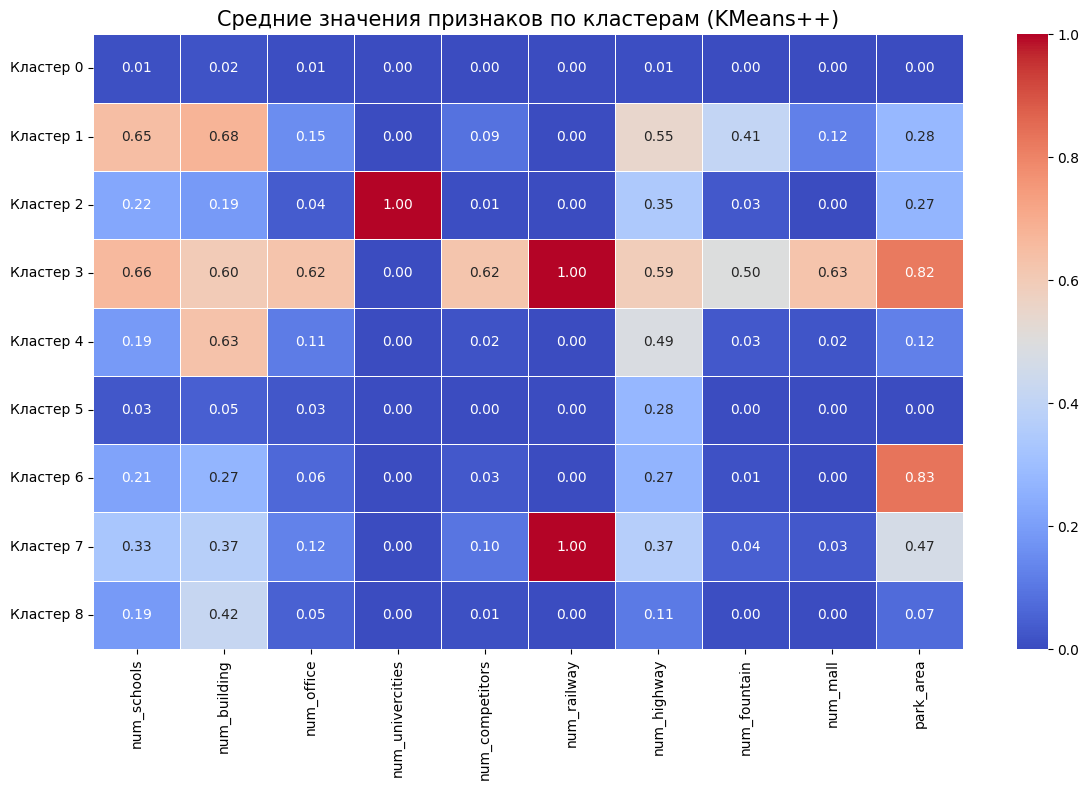

In [ ]:
X_clust_df['index_score'] = y
X_clust_df.groupby('cluster')['index_score'].describe()

# Создаем тепловую карту средних значений признаков по кластерам
unique_clusters = np.unique(labels)
# Вычисляем средние значения признаков для каждого кластера
cluster_means = []
for cluster in unique_clusters:
    if cluster != -1:  # Пропускаем шумовые точки
        cluster_data = X[labels == cluster]
        cluster_means.append(cluster_data.mean(axis=0))

# Создаем DataFrame для тепловой карты
cluster_means_df = pd.DataFrame(
    cluster_means,
    index=[f'Кластер {i}' for i in unique_clusters if i != -1],
    columns=columns
)

# Визуализируем тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Средние значения признаков по кластерам (KMeans++)', fontsize=15)
plt.tight_layout()
plt.show()

### **Часть 4. Расчет потенциала локаций и финальные рекомендации**



1. **Разработка интегрального показателя потенциала**:
   - Самостоятельно определите веса для факторов привлекательности среды и конкуренции
   - Обоснуйте выбранные веса в контексте вашего бизнеса
   - Рассчитайте итоговый потенциал для всех ячеек сетки
   - Категоризируйте потенциал для упрощения интерпретации результатов

2. **Визуализация результатов**:
   - Создайте интерактивную карту с тепловым слоем потенциала
   - Добавьте маркеры существующих объектов вашего типа бизнеса
   - Выделите топ-10 локаций с наивысшим потенциалом
   - Подготовьте отдельную карту фокуса на лучших локациях

3. **Формирование бизнес-рекомендаций**:
   - Составьте список из 5-7 конкретных локаций для размещения новых объектов
   - Для каждой рекомендуемой локации укажите:
     * Точные координаты
     * Значение потенциала
     * Ключевые характеристики локации
     * Преимущества и возможные риски размещения в данной точке
   - Подготовьте общие рекомендации по стратегии территориального развития для выбранного бизнеса

In [ ]:
clust_gdf = h3_gdf.copy()
scaler = MinMaxScaler()
clust_gdf['index_score'] = scaler.fit_transform(pd.DataFrame(clust_gdf['index_score']))
clust_gdf['cluster'] = X_clust_df['cluster'].astype(str)
bins = [0.0, 0.5, 0.7, 0.8, 0.9, 1.0]

labels = ['1', '2', '3', '4', '5']

clust_gdf['cat'] = pd.cut(
    clust_gdf['index_score'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
).astype(str)

m4 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

m4.add_data(
    clust_gdf,
    column="cat",
    cmap="OrRd",
    legend_title="cat",
    layer_name="H3 Сетка",
    scheme='EqualInterval',
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    },
    info_mode='on_click'
)

m4.add_gdf(cafes, layer_name='Уютное кафе', info_mode='on_click')
m4

Map(center=[55.87645, 38.44345], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

In [ ]:
best_gdf = clust_gdf.sort_values('index_score', ascending=False).head(10)
best_gdf

,h3_index,geometry,num_schools,num_building,num_office,num_univercities,num_competitors,num_railway,num_highway,num_fountain,num_mall,park_area,index_score,cluster,cat
825,89118c892afffff,"POLYGON ((4279192.155 7529679.67, 4279458.291 ...",0.9,0.762931,0.6875,0.0,0.857143,1.0,0.7,0.833333,0.833333,1.000000,1.000000,3,5
1322,89118c892a3ffff,"POLYGON ((4278614.393 7529744.728, 4278880.536...",0.9,0.689655,0.7500,0.0,0.857143,1.0,0.6,1.000000,1.000000,1.000000,0.997990,3,5
585,89118c892abffff,"POLYGON ((4278835.066 7529171.093, 4279101.189...",0.5,0.586207,1.0000,0.0,1.000000,1.0,0.9,0.500000,0.916667,1.000000,0.988498,3,5
1350,89118c89233ffff,"POLYGON ((4279412.795 7529106.011, 4279678.911...",0.6,0.625000,0.6875,0.0,0.785714,1.0,0.7,0.333333,0.750000,0.877457,0.879218,3,4
621,89118c892a7ffff,"POLYGON ((4278971.487 7530253.352, 4279237.644...",1.0,0.771552,0.7500,0.0,0.714286,1.0,0.5,1.000000,0.750000,0.224996,0.873233,3,4
528,89118c893dbffff,"POLYGON ((4279549.296 7530188.274, 4279815.447...",0.8,0.866379,0.5000,0.0,0.214286,1.0,0.6,0.333333,0.333333,0.224996,0.845544,3,4
436,89118c89217ffff,"POLYGON ((4278478.032 7528662.542, 4278744.14 ...",0.5,0.405172,0.5000,0.0,0.214286,1.0,0.9,0.333333,0.500000,1.000000,0.791161,3,3
1278,89118c892bbffff,"POLYGON ((4278257.353 7529236.13, 4278523.481 ...",0.5,0.409483,0.7500,0.0,0.642857,1.0,0.4,0.333333,0.666667,1.000000,0.774394,3,3
1137,89118c893cbffff,"POLYGON ((4280127.121 7530123.15, 4280393.266 ...",0.9,0.814655,0.4375,0.0,0.000000,1.0,0.6,0.000000,0.000000,0.100794,0.744779,7,3
495,89118c893d7ffff,"POLYGON ((4279685.835 7531270.68, 4279952.021 ...",0.8,0.969828,0.2500,0.0,0.071429,0.0,0.7,0.000000,0.166667,0.166395,0.725557,1,3


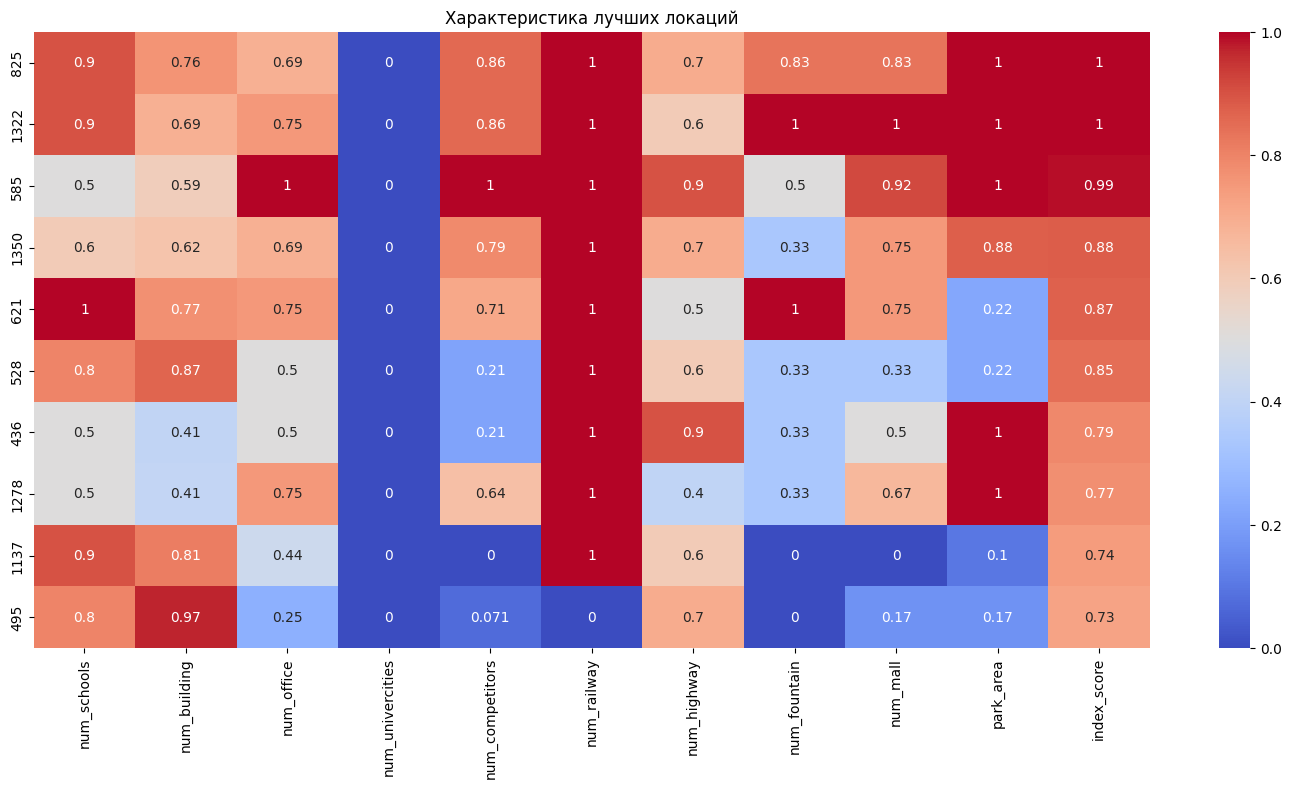

In [ ]:
fin_feat = columns.copy()
fin_feat.append('index_score')

plt.figure(figsize=(18, 8))
sns.heatmap(best_gdf[fin_feat], annot=True, cmap='coolwarm')
plt.title('Характеристика лучших локаций')
plt.show()

In [ ]:
mapa = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

data = []
for h3_id in best_gdf['h3_index']:
    lat, lng = h3.h3_to_geo(h3_id)
    data.append({'h3_id': h3_id, 'lat': lat, 'lng': lng})

df_centers = pd.DataFrame(data)
gdf_centers = gpd.GeoDataFrame(
    df_centers,
    geometry=gpd.points_from_xy(df_centers['lng'], df_centers['lat']),
    crs="EPSG:4326"  # WGS 84 coordinate system
)

mapa.add_gdf(
    gdf_centers,
    layer_name="best points",
    info_mode='on_click'
)

mapa.add_data(
    best_gdf,
    column='index_score',
    cmap="Purples",
    k=11,
    layer_name="H3 Сетка",
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    },
    info_mode='on_click'
)

mapa

Map(center=[55.87645, 38.44345], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

**ТОП 1: ТОРГОВЫЙ ЦЕНТР "РАССВЕТ"**
- адресс: ул. 3-го Интернационала, 52
- точные координаты: 55.856624, 38.443304
- значение потенциала: 1
- ключевые характеристики: торговый центр, большой поток людей, близость центра
- преимущества: большой поток клиентов
- риски: минимальные. Возможно открытие конкурентов

**ТОП 2: БЛИЗ ПЛОЩАДИ БУГРОВА**
- адресс: улица 3-го Интернационала, 70
- точные координаты: 55.855244, 38.438740
- значение потенциала: 0.998
- ключевые характеристики: театр, парк, тц
- преимущества: большой поток посетителей
- риски: вокруг много конкурентов

**ТОП 3: Трудовая улица, 6**
- адресс: Трудовая улица, 6
- точные координаты: 55.852981, 38.439621
- значение потенциала: 0,879
- ключевые характеристики: близко автовокзал
- преимущества: близкая доступность
- риски: большая стоимость аренды

**ТОП 4: Комсомольская улица, 26**
- адресс: Комсомольская улица, 26
- точные координаты: 55.852576, 38.445020
- значение потенциала: 0.877
- ключевые характеристики: тц, спальный район
- преимущества: постоянные клиенты
- риски: малый поток клиентов

**ТОП 5: Рабочая улица, 12А**
- адресс: Рабочая улица, 12А
- точные координаты: 55.858175, 38.441211
- значение потенциала: 0.873
- ключевые характеристики: у набережной
- преимущества: большой поток клиентов
- риски: у воды в холодные сезоны ветренно

## **Рекомендации по выполнению**


1. Начните с малой территории для тестирования кода и методологии, затем расширяйте анализ.
2. Используйте инкрементальный подход: сначала реализуйте базовый функционал, затем улучшайте его.
3. Регулярно сохраняйте промежуточные результаты работы.
4. При выборе признаков опирайтесь не только на учебный материал, но и на научные статьи по геоанализу и геомаркетингу.
5. Обращайте внимание на особенности территории и уникальные характеристики выбранного бизнеса.
6. Для оценки результатов старайтесь сопоставить их с реальным расположением успешных объектов аналогичного бизнеса.